# Stoppage Time Goals Analysis

Exploring goals scored in stoppage time (90+ minutes) during the 2nd half of matches.

In [405]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [406]:
# Load all match shots data
raw_data_dir = Path('../data/raw/mt1cfl_2526/raw_by_match')
all_shots = []

for match_dir in raw_data_dir.iterdir():
    if match_dir.is_dir():
        shots_file = match_dir / 'match_shots.csv'
        if shots_file.exists():
            try:
                match_id = match_dir.name
                df = pd.read_csv(shots_file)
                if len(df) > 0:  # Only add if not empty
                    df['match_id'] = match_id
                    all_shots.append(df)
            except pd.errors.EmptyDataError:
                # Skip empty files
                continue

# Combine all shots data
shots_df = pd.concat(all_shots, ignore_index=True)

print(f"Total shots: {len(shots_df)}")
print(f"Total goals: {len(shots_df[shots_df['shotType'] == 'goal'])}")

Total shots: 2022
Total goals: 238


In [407]:
# Filter for goals only
goals_df = shots_df[shots_df['shotType'] == 'goal'].copy()

# Filter for stoppage time goals (90+ minutes)
stoppage_time_goals = goals_df[goals_df['time'] >= 90].copy()

In [408]:
# Parse player info from JSON string
import ast

def parse_player_name(player_str):
    try:
        player_dict = ast.literal_eval(player_str)
        return player_dict.get('name', 'Unknown')
    except:
        return 'Unknown'

stoppage_time_goals['player_name'] = stoppage_time_goals['player'].apply(parse_player_name)

# Show stoppage time goals with player details
stoppage_cols = ['player_name', 'time', 'addedTime', 'isHome', 'situation', 'bodyPart', 'xg']
print("\nStoppage Time Goals Details:")
print(stoppage_time_goals[stoppage_cols].to_string(index=False))


Stoppage Time Goals Details:
      player_name  time  addedTime  isHome situation   bodyPart      xg
Anđelko Jovanović    90        NaN    True   regular right-foot 0.45400
    Vasko Kalezić    90        3.0    True   regular right-foot 0.18020
   Andrej Pupović    90        5.0   False free-kick  left-foot 0.08781
    Žarko Popović    90        3.0    True   regular  left-foot 0.28330
    Dušan Vuković    90        1.0    True   penalty right-foot 0.76000
   Halil Kajoshaj    90        3.0    True   regular right-foot 0.15720
  Milan Vušurović    90        4.0    True   regular right-foot 0.15780
    Marko Đurišić    90        2.0    True   regular  left-foot 0.14060
    Aldin Adžović    90        3.0    True   regular right-foot 0.32190
    Vuk Striković    90        2.0    True   regular       head 0.17060
    Vasko Kalezić    90        NaN    True   regular right-foot 0.06652
   Ognjen Rolović    90        3.0    True   penalty right-foot 0.76000
   Draško Božović    90        5.0

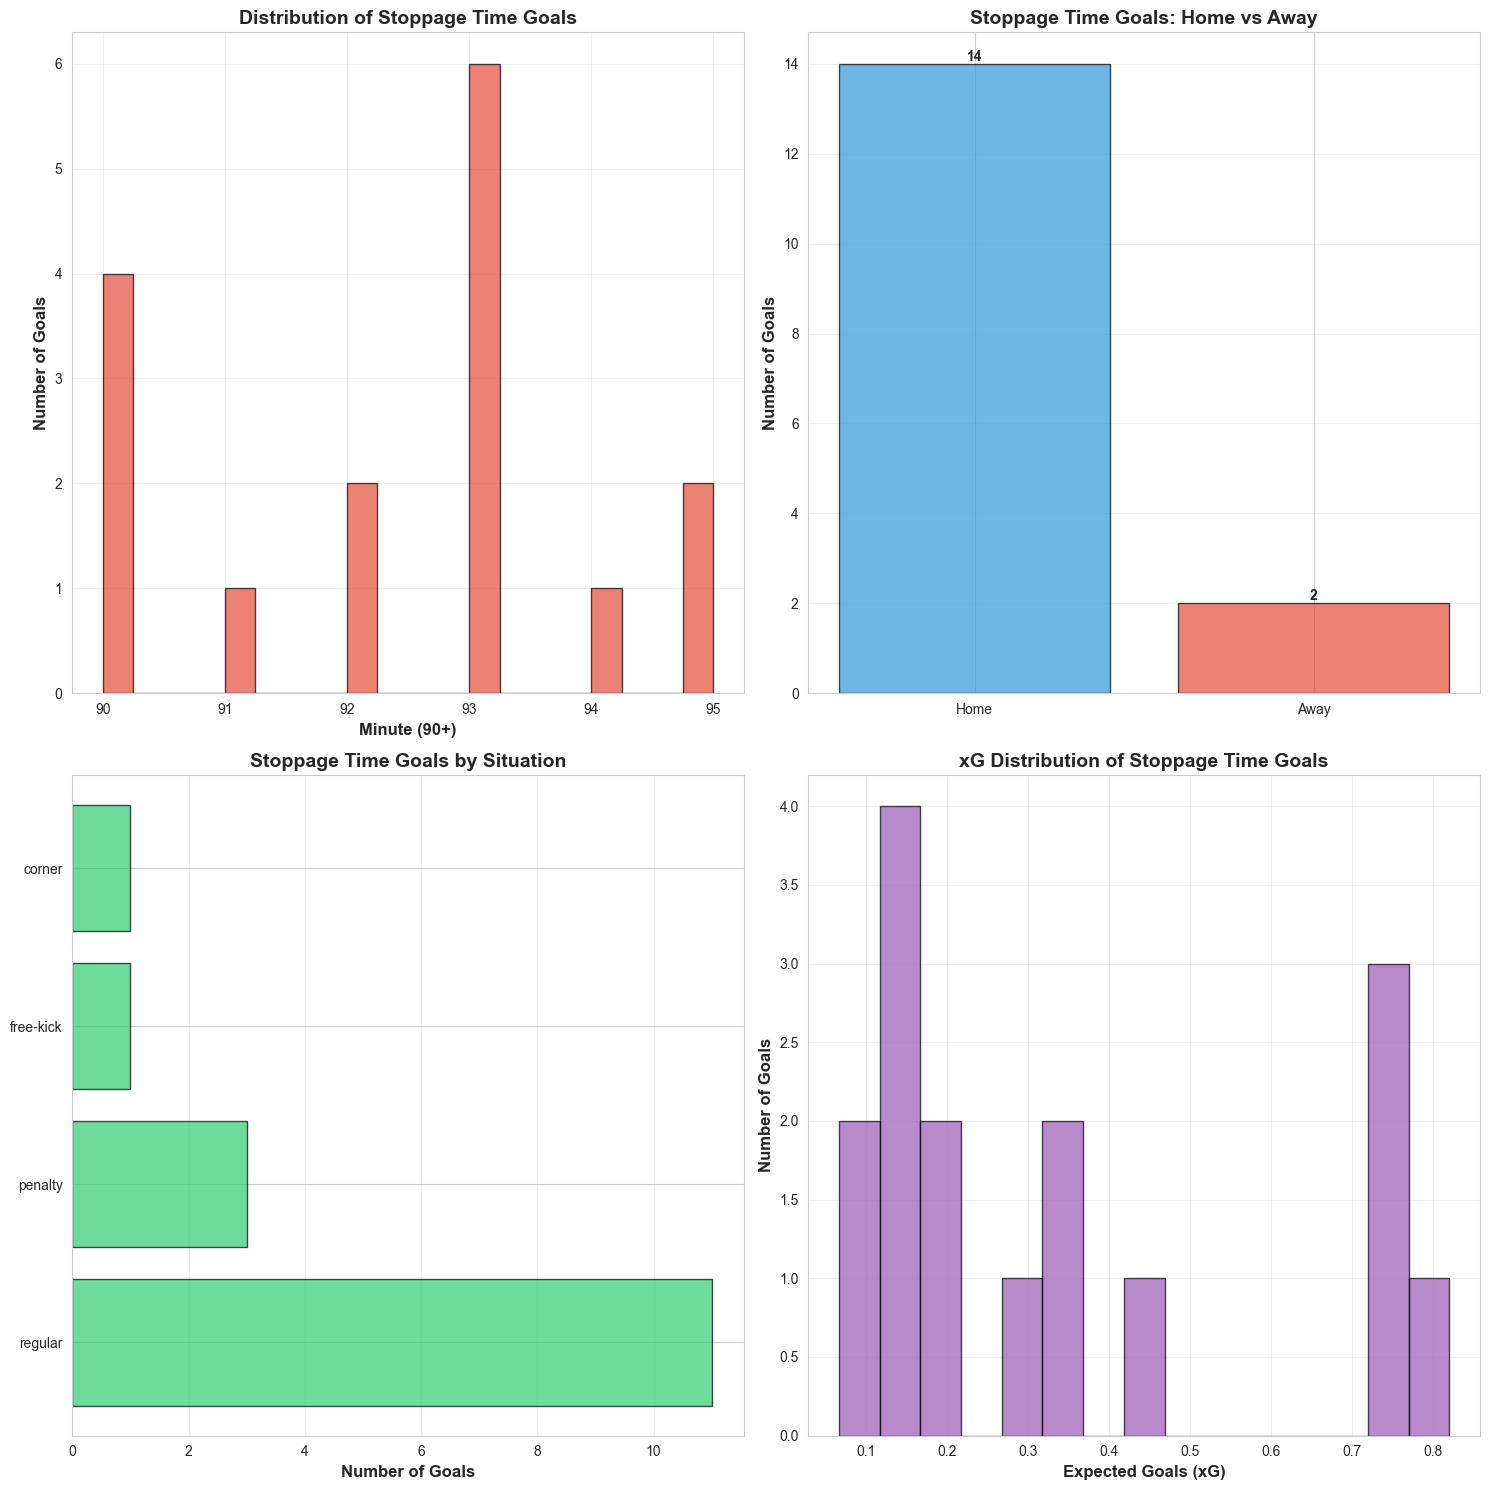

In [409]:
# Visualize stoppage time goals
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

# 1. Distribution of stoppage time goals by minute + added time
ax1 = axes[0, 0]
stoppage_time_goals['exact_time'] = stoppage_time_goals['time'] + stoppage_time_goals['addedTime'].fillna(0)
stoppage_time_goals['exact_time'].hist(bins=20, ax=ax1, color='#e74c3c', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Minute (90+)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Goals', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Stoppage Time Goals', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)

# 2. Home vs Away
ax2 = axes[0, 1]
home_away_counts = stoppage_time_goals['isHome'].value_counts()
home_away_counts.index = ['Home', 'Away']
colors = ['#3498db', '#e74c3c']
bars = ax2.bar(home_away_counts.index, home_away_counts.values, color=colors, edgecolor='black', alpha=0.7)
ax2.set_ylabel('Number of Goals', fontsize=12, fontweight='bold')
ax2.set_title('Stoppage Time Goals: Home vs Away', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3, axis='y')

# Add values on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold')

# 3. By situation
ax3 = axes[1, 0]
situation_counts = stoppage_time_goals['situation'].value_counts().head(8)
ax3.barh(situation_counts.index, situation_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Number of Goals', fontsize=12, fontweight='bold')
ax3.set_title('Stoppage Time Goals by Situation', fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3, axis='x')

# 4. Expected Goals (xG) distribution
ax4 = axes[1, 1]
stoppage_time_goals['xg'].hist(bins=15, ax=ax4, color='#9b59b6', edgecolor='black', alpha=0.7)
ax4.set_xlabel('Expected Goals (xG)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Number of Goals', fontsize=12, fontweight='bold')
ax4.set_title('xG Distribution of Stoppage Time Goals', fontsize=14, fontweight='bold')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [410]:
# Additional statistics
print("STOPPAGE TIME GOALS STATISTICS")
print("="*80)
print(f"\nTotal matches analyzed: {shots_df['match_id'].nunique()}")
print(f"Total goals scored: {len(goals_df)}")
print(f"Stoppage time goals (90+): {len(stoppage_time_goals)}")
print(f"Percentage of all goals: {len(stoppage_time_goals) / len(goals_df) * 100:.2f}%")

print(f"\n{'='*80}")
print("BREAKDOWN BY BODY PART:")
print(f"{'='*80}")
body_part_counts = stoppage_time_goals['bodyPart'].value_counts()
for body_part, count in body_part_counts.items():
    print(f"  {body_part}: {count} goals ({count/len(stoppage_time_goals)*100:.1f}%)")

print(f"\n{'='*80}")
print("TOP SCORERS IN STOPPAGE TIME:")
print(f"{'='*80}")
top_scorers = stoppage_time_goals['player_name'].value_counts().head(10)
for i, (player, count) in enumerate(top_scorers.items(), 1):
    print(f"  {i}. {player}: {count} goal(s)")

print(f"\n{'='*80}")
print("AVERAGE xG:")
print(f"{'='*80}")
print(f"  All goals: {goals_df['xg'].mean():.4f}")
print(f"  Stoppage time goals: {stoppage_time_goals['xg'].mean():.4f}")

STOPPAGE TIME GOALS STATISTICS

Total matches analyzed: 95
Total goals scored: 238
Stoppage time goals (90+): 16
Percentage of all goals: 6.72%

BREAKDOWN BY BODY PART:
  right-foot: 12 goals (75.0%)
  left-foot: 3 goals (18.8%)
  head: 1 goals (6.2%)

TOP SCORERS IN STOPPAGE TIME:
  1. Vasko Kalezić: 2 goal(s)
  2. Jagoš Roganović: 2 goal(s)
  3. Anđelko Jovanović: 1 goal(s)
  4. Andrej Pupović: 1 goal(s)
  5. Žarko Popović: 1 goal(s)
  6. Dušan Vuković: 1 goal(s)
  7. Halil Kajoshaj: 1 goal(s)
  8. Milan Vušurović: 1 goal(s)
  9. Marko Đurišić: 1 goal(s)
  10. Aldin Adžović: 1 goal(s)

AVERAGE xG:
  All goals: 0.2914
  Stoppage time goals: 0.3502


## Impact on Standings - Stoppage Time (90+)

In [411]:
# Load match metadata
matches_df = pd.read_csv('../data/processed/matches_metadata.csv')
matches_df['match_id'] = matches_df['match_id'].astype(str)

# Merge stoppage time goals with match data
stoppage_goals_with_teams = stoppage_time_goals.merge(
    matches_df[['match_id', 'homeTeam_name', 'awayTeam_name']], 
    on='match_id', 
    how='left'
)

stoppage_goals_with_teams['scoring_team'] = stoppage_goals_with_teams.apply(
    lambda row: row['homeTeam_name'] if row['isHome'] else row['awayTeam_name'], 
    axis=1
)

# Count stoppage time goals per match and team
stoppage_goals_per_match = stoppage_goals_with_teams.groupby(['match_id', 'scoring_team']).size().reset_index(name='stoppage_goals')

# Create adjusted matches
matches_adjusted = matches_df.copy()

home_stoppage = stoppage_goals_per_match.rename(columns={'scoring_team': 'homeTeam_name', 'stoppage_goals': 'home_stoppage_goals'})
matches_adjusted = matches_adjusted.merge(
    home_stoppage[['match_id', 'homeTeam_name', 'home_stoppage_goals']], 
    on=['match_id', 'homeTeam_name'], 
    how='left'
)

away_stoppage = stoppage_goals_per_match.rename(columns={'scoring_team': 'awayTeam_name', 'stoppage_goals': 'away_stoppage_goals'})
matches_adjusted = matches_adjusted.merge(
    away_stoppage[['match_id', 'awayTeam_name', 'away_stoppage_goals']], 
    on=['match_id', 'awayTeam_name'], 
    how='left'
)

matches_adjusted['home_stoppage_goals'] = matches_adjusted['home_stoppage_goals'].fillna(0).astype(int)
matches_adjusted['away_stoppage_goals'] = matches_adjusted['away_stoppage_goals'].fillna(0).astype(int)

matches_adjusted['homeScore_adjusted'] = matches_adjusted['homeScore_total'] - matches_adjusted['home_stoppage_goals']
matches_adjusted['awayScore_adjusted'] = matches_adjusted['awayScore_total'] - matches_adjusted['away_stoppage_goals']

# Function to calculate standings
def calculate_standings(matches, home_score_col, away_score_col):
    standings = {}
    
    for _, match in matches.iterrows():
        home_team = match['homeTeam_name']
        away_team = match['awayTeam_name']
        home_score = match[home_score_col]
        away_score = match[away_score_col]
        
        if home_team not in standings:
            standings[home_team] = {'P': 0, 'W': 0, 'D': 0, 'L': 0, 'GF': 0, 'GA': 0, 'GD': 0, 'Pts': 0}
        if away_team not in standings:
            standings[away_team] = {'P': 0, 'W': 0, 'D': 0, 'L': 0, 'GF': 0, 'GA': 0, 'GD': 0, 'Pts': 0}
        
        standings[home_team]['P'] += 1
        standings[away_team]['P'] += 1
        standings[home_team]['GF'] += home_score
        standings[home_team]['GA'] += away_score
        standings[away_team]['GF'] += away_score
        standings[away_team]['GA'] += home_score
        
        if home_score > away_score:
            standings[home_team]['W'] += 1
            standings[home_team]['Pts'] += 3
            standings[away_team]['L'] += 1
        elif away_score > home_score:
            standings[away_team]['W'] += 1
            standings[away_team]['Pts'] += 3
            standings[home_team]['L'] += 1
        else:
            standings[home_team]['D'] += 1
            standings[away_team]['D'] += 1
            standings[home_team]['Pts'] += 1
            standings[away_team]['Pts'] += 1
    
    for team in standings:
        standings[team]['GD'] = standings[team]['GF'] - standings[team]['GA']
    
    standings_df = pd.DataFrame.from_dict(standings, orient='index')
    standings_df = standings_df.sort_values(['Pts', 'GD', 'GF'], ascending=[False, False, False])
    standings_df.insert(0, 'Team', standings_df.index)
    standings_df.insert(0, 'Pos', range(1, len(standings_df) + 1))
    standings_df = standings_df.reset_index(drop=True)
    
    return standings_df

# Calculate standings
actual_standings = calculate_standings(matches_adjusted, 'homeScore_total', 'awayScore_total')
adjusted_standings = calculate_standings(matches_adjusted, 'homeScore_adjusted', 'awayScore_adjusted')

# Create comparison
comparison = actual_standings[['Team', 'Pos', 'Pts', 'GD']].copy()
comparison.columns = ['Team', 'Actual_Pos', 'Actual_Pts', 'Actual_GD']

adjusted_comp = adjusted_standings[['Team', 'Pos', 'Pts', 'GD']].copy()
adjusted_comp.columns = ['Team', 'Adjusted_Pos', 'Adjusted_Pts', 'Adjusted_GD']

comparison = comparison.merge(adjusted_comp, on='Team')
comparison['Pos_Change'] = comparison['Actual_Pos'] - comparison['Adjusted_Pos']
comparison['Pts_Diff'] = comparison['Actual_Pts'] - comparison['Adjusted_Pts']
comparison['GD_Diff'] = comparison['Actual_GD'] - comparison['Adjusted_GD']
comparison['Pts_Diff'] = comparison['Pts_Diff'].astype(int)
comparison['GD_Diff'] = comparison['GD_Diff'].astype(int)

def pos_change_arrow(change):
    if change > 0:
        return f"↓{abs(int(change))}"  # Positive = worse position in alternate (higher position number)
    elif change < 0:
        return f"↑{abs(int(change))}"  # Negative = better position in alternate (lower position number)
    else:
        return "="

comparison['Change'] = comparison['Pos_Change'].apply(pos_change_arrow)
comparison = comparison.sort_values('Actual_Pos')

print("\nSTANDINGS COMPARISON:")
print("="*100)
print(f"{'Team':<25} {'Actual':<15} {'Without 90+':<15} {'Change':<10} {'Pts Diff':<10} {'GD Diff'}")
print("="*100)

for _, row in comparison.iterrows():
    actual_str = f"{int(row['Actual_Pos'])}. ({int(row['Actual_Pts'])} pts)"
    adjusted_str = f"{int(row['Adjusted_Pos'])}. ({int(row['Adjusted_Pts'])} pts)"
    print(f"{row['Team']:<25} {actual_str:<15} {adjusted_str:<15} {row['Change']:<10} {row['Pts_Diff']:>+3d}       {row['GD_Diff']:>+3d}")

print("="*100)
print(f"\nTeams that would change position: {len(comparison[comparison['Pos_Change'] != 0])}")
if len(comparison[comparison['Pts_Diff'] > 0]) > 0:
    print(f"Biggest beneficiary: {comparison.loc[comparison['Pts_Diff'].idxmax(), 'Team']} (+{comparison['Pts_Diff'].max()} pts)")
if len(comparison[comparison['Pts_Diff'] < 0]) > 0:
    print(f"Biggest victim: {comparison.loc[comparison['Pts_Diff'].idxmin(), 'Team']} ({comparison['Pts_Diff'].min()} pts)")


STANDINGS COMPARISON:
Team                      Actual          Without 90+     Change     Pts Diff   GD Diff
FK Sutjeska Nikšić        1. (36 pts)     1. (36 pts)     =           +0        +2
FK Mornar Bar             2. (32 pts)     2. (32 pts)     =           +0        +0
FK Dečić Tuzi             3. (31 pts)     5. (27 pts)     ↑2          +4        +1
FK Jezero                 4. (29 pts)     3. (28 pts)     ↓1          +1        +1
OFK Petrovac              5. (26 pts)     7. (25 pts)     ↑2          +1        +2
Mladost DG                6. (26 pts)     6. (26 pts)     =           +0        +2
FK Budućnost Podgorica    7. (25 pts)     4. (27 pts)     ↓3          -2        -2
FK Arsenal Tivat          8. (20 pts)     8. (20 pts)     =           +0        -2
FK Bokelj Kotor           9. (19 pts)     9. (19 pts)     =           +0        -1
FK Jedinstvo Bijelo Polje 10. (15 pts)    10. (16 pts)    =           -1        -3

Teams that would change position: 4
Biggest beneficiary: F

## Late Game Performance - Goals After 70 Minutes

Analyzing team stamina and performance in the final 20+ minutes of matches.

In [412]:
# Filter for late game goals (70+ minutes)
late_game_goals = goals_df[goals_df['time'] >= 70].copy()

print(f"Total goals scored: {len(goals_df)}")
print(f"Goals after 70 minutes: {len(late_game_goals)}")
print(f"Percentage: {len(late_game_goals) / len(goals_df) * 100:.1f}%\n")

# Merge with match data
late_goals_with_teams = late_game_goals.merge(
    matches_df[['match_id', 'homeTeam_name', 'awayTeam_name']], 
    on='match_id', 
    how='left'
)

late_goals_with_teams['scoring_team'] = late_goals_with_teams.apply(
    lambda row: row['homeTeam_name'] if row['isHome'] else row['awayTeam_name'], 
    axis=1
)

# Count late game goals per match and team
late_goals_per_match = late_goals_with_teams.groupby(['match_id', 'scoring_team']).size().reset_index(name='late_goals')

# Create adjusted matches
matches_late_adjusted = matches_df.copy()

home_late = late_goals_per_match.rename(columns={'scoring_team': 'homeTeam_name', 'late_goals': 'home_late_goals'})
matches_late_adjusted = matches_late_adjusted.merge(
    home_late[['match_id', 'homeTeam_name', 'home_late_goals']], 
    on=['match_id', 'homeTeam_name'], 
    how='left'
)

away_late = late_goals_per_match.rename(columns={'scoring_team': 'awayTeam_name', 'late_goals': 'away_late_goals'})
matches_late_adjusted = matches_late_adjusted.merge(
    away_late[['match_id', 'awayTeam_name', 'away_late_goals']], 
    on=['match_id', 'awayTeam_name'], 
    how='left'
)

matches_late_adjusted['home_late_goals'] = matches_late_adjusted['home_late_goals'].fillna(0).astype(int)
matches_late_adjusted['away_late_goals'] = matches_late_adjusted['away_late_goals'].fillna(0).astype(int)

matches_late_adjusted['homeScore_adjusted'] = matches_late_adjusted['homeScore_total'] - matches_late_adjusted['home_late_goals']
matches_late_adjusted['awayScore_adjusted'] = matches_late_adjusted['awayScore_total'] - matches_late_adjusted['away_late_goals']

# Calculate standings
actual_standings_70 = calculate_standings(matches_late_adjusted, 'homeScore_total', 'awayScore_total')
adjusted_standings_70 = calculate_standings(matches_late_adjusted, 'homeScore_adjusted', 'awayScore_adjusted')

# Create comparison
comparison_70 = actual_standings_70[['Team', 'Pos', 'Pts', 'GD']].copy()
comparison_70.columns = ['Team', 'Actual_Pos', 'Actual_Pts', 'Actual_GD']

adjusted_comp_70 = adjusted_standings_70[['Team', 'Pos', 'Pts', 'GD']].copy()
adjusted_comp_70.columns = ['Team', 'Adjusted_Pos', 'Adjusted_Pts', 'Adjusted_GD']

comparison_70 = comparison_70.merge(adjusted_comp_70, on='Team')
comparison_70['Pos_Change'] = comparison_70['Adjusted_Pos'] - comparison_70['Actual_Pos']  # Inverted: alternate - actual
comparison_70['Pts_Diff'] = comparison_70['Adjusted_Pts'] - comparison_70['Actual_Pts']  # Inverted: alternate - actual
comparison_70['GD_Diff'] = comparison_70['Adjusted_GD'] - comparison_70['Actual_GD']  # Inverted: alternate - actual
comparison_70['Pts_Diff'] = comparison_70['Pts_Diff'].astype(int)
comparison_70['GD_Diff'] = comparison_70['GD_Diff'].astype(int)

comparison_70['Change'] = comparison_70['Pos_Change'].apply(pos_change_arrow)
comparison_70 = comparison_70.sort_values('Actual_Pos')

print("\nSTANDINGS COMPARISON:")
print("="*100)
print(f"{'Team':<25} {'Actual':<15} {'Without 70+':<15} {'Change':<10} {'Pts Diff':<10} {'GD Diff'}")
print("="*100)

for _, row in comparison_70.iterrows():
    actual_str = f"{int(row['Actual_Pos'])}. ({int(row['Actual_Pts'])} pts)"
    adjusted_str = f"{int(row['Adjusted_Pos'])}. ({int(row['Adjusted_Pts'])} pts)"
    print(f"{row['Team']:<25} {actual_str:<15} {adjusted_str:<15} {row['Change']:<10} {row['Pts_Diff']:>+3d}       {row['GD_Diff']:>+3d}")

print("="*100)
print(f"\nTeams that would change position: {len(comparison_70[comparison_70['Pos_Change'] != 0])}")
if len(comparison_70[comparison_70['Pts_Diff'] > 0]) > 0:
    print(f"Best late-game performers: {comparison_70.loc[comparison_70['Pts_Diff'].idxmax(), 'Team']} (+{comparison_70['Pts_Diff'].max()} pts)")
if len(comparison_70[comparison_70['Pts_Diff'] < 0]) > 0:
    print(f"Worst late-game performers: {comparison_70.loc[comparison_70['Pts_Diff'].idxmin(), 'Team']} ({comparison_70['Pts_Diff'].min()} pts)")

Total goals scored: 238
Goals after 70 minutes: 73
Percentage: 30.7%


STANDINGS COMPARISON:
Team                      Actual          Without 70+     Change     Pts Diff   GD Diff
FK Sutjeska Nikšić        1. (36 pts)     1. (35 pts)     =           -1        -3
FK Mornar Bar             2. (32 pts)     4. (28 pts)     ↓2          -4        -2
FK Dečić Tuzi             3. (31 pts)     7. (22 pts)     ↓4          -9        +1
FK Jezero                 4. (29 pts)     3. (30 pts)     ↑1          +1        -2
OFK Petrovac              5. (26 pts)     5. (26 pts)     =           +0        +0
Mladost DG                6. (26 pts)     6. (24 pts)     =           -2        -3
FK Budućnost Podgorica    7. (25 pts)     2. (30 pts)     ↑5          +5        +3
FK Arsenal Tivat          8. (20 pts)     8. (21 pts)     =           +1        +4
FK Bokelj Kotor           9. (19 pts)     10. (17 pts)    ↓1          -2        -3
FK Jedinstvo Bijelo Polje 10. (15 pts)    9. (19 pts)     ↑1          +4

## Visual Comparison - Late Game Stamina Impact

✅ Figure saved to: outputs/final_posts/late_game_stamina_analysis.png


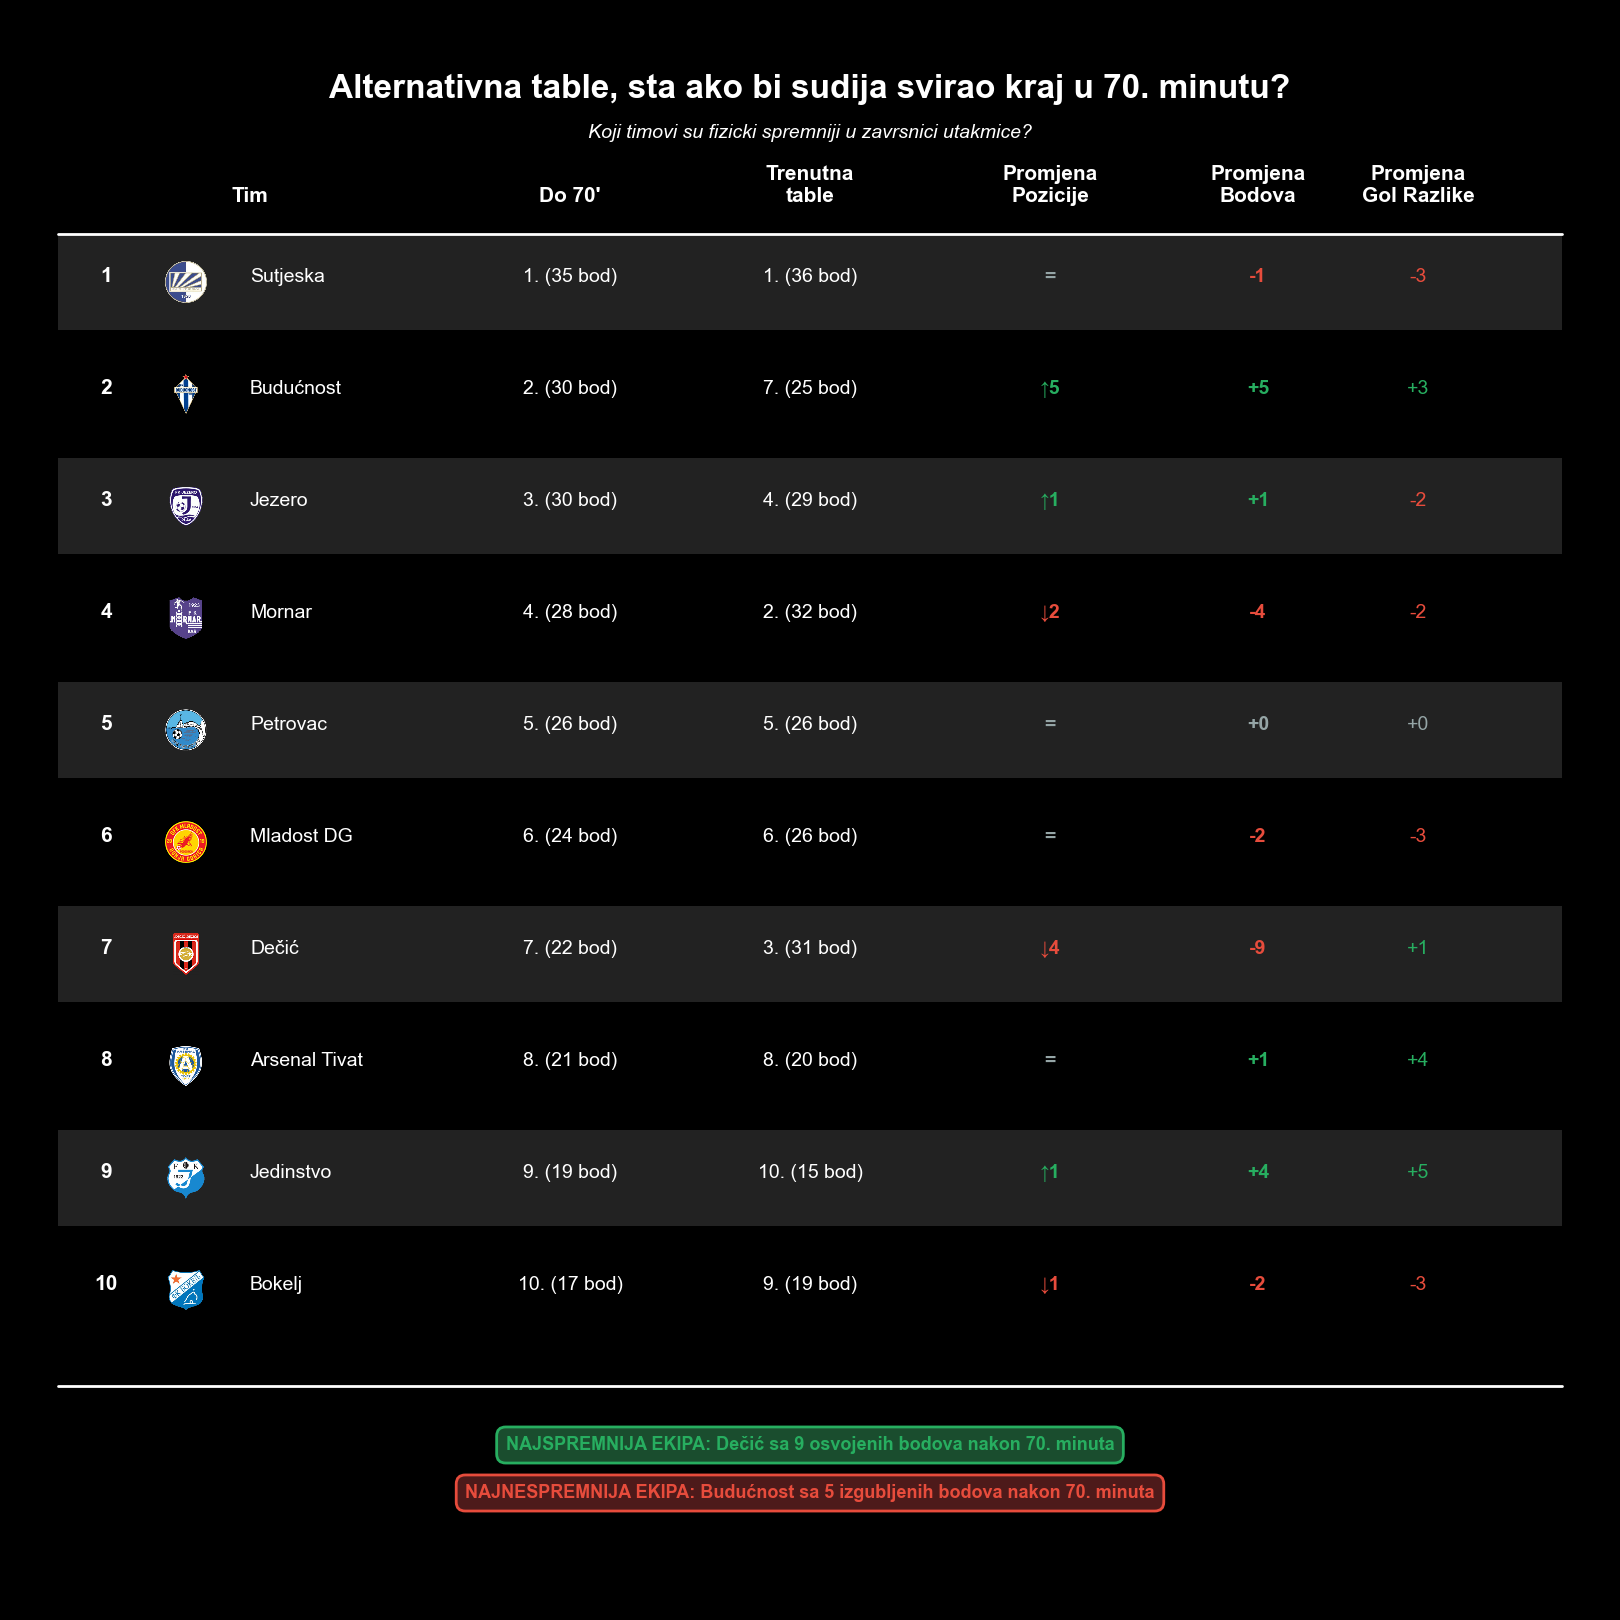

In [413]:
# Load team metadata for short names and logos
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

teams_metadata = pd.read_csv('../data/processed/teams_metadata.csv')
teams_metadata['short_name'] = teams_metadata['short_name'].str.strip()

# Merge short names with comparison data
comparison_viz = comparison_70.merge(
    teams_metadata[['team_name', 'short_name', 'team_id']], 
    left_on='Team', 
    right_on='team_name',
    how='left'
)

# Sort by adjusted position (Without 70+)
comparison_viz = comparison_viz.sort_values('Adjusted_Pos').reset_index(drop=True)

# Create the visual comparison figure with black background
fig, ax = plt.subplots(figsize=(16, 16), facecolor='black')
ax.axis('off')
ax.set_position([0, 0, 1, 1])  # Make axis span full figure
fig.patch.set_facecolor('black')

# Title in Serbian
fig.suptitle('Alternativna table, sta ako bi sudija svirao kraj u 70. minutu?', 
             fontsize=24, fontweight='bold', y=0.96, color='white')
plt.text(0.5, 0.92, 'Koji timovi su fizicki spremniji u zavrsnici utakmice?', 
         ha='center', fontsize=14, transform=fig.transFigure, style='italic', color='white')

# Table dimensions
num_teams = len(comparison_viz)
col_width = 0.1
row_height = 0.07
start_y = 0.88

# Column headers
headers = ['', 'Tim', 'Do 70\'', 'Trenutna\ntable', 'Promjena\nPozicije', 'Promjena\nBodova', 'Promjena\nGol Razlike']
header_positions = [0.05, 0.15, 0.35, 0.50, 0.65, 0.78, 0.88]

for i, (header, x_pos) in enumerate(zip(headers, header_positions)):
    ax.text(x_pos, start_y, header, 
            fontsize=15, fontweight='bold', ha='center', transform=fig.transFigure, color='white')

# Divider line after header
ax.plot([0.03, 0.97], [start_y - 0.02, start_y - 0.02], 
        color='white', linewidth=2, transform=fig.transFigure)

# Draw table rows
for idx, row in comparison_viz.iterrows():
    y_pos = start_y - 0.05 - (idx * row_height)
    
    # Alternate row background
    if idx % 2 == 0:
        rect = plt.Rectangle((0.03, y_pos - 0.03), 0.94, row_height - 0.01,
                             facecolor='#222222', edgecolor='none', 
                             transform=fig.transFigure, zorder=0)
        ax.add_patch(rect)
    
    # Position number (based on Adjusted_Pos)
    ax.text(0.06, y_pos, f"{int(row['Adjusted_Pos'])}",
            fontsize=15, fontweight='bold', ha='center', transform=fig.transFigure, color='white')
    
    # Team logo (bigger size)
    logo_path = f"../data/processed/team_logos/{int(row['team_id'])}.png"
    try:
        logo = Image.open(logo_path).convert('RGBA')  # Ensure proper color handling
        imagebox = OffsetImage(logo, zoom=0.2)  # Increased to 0.18 for better visibility
        ab = AnnotationBbox(imagebox, (0.11, y_pos), 
                           frameon=False, xycoords=fig.transFigure)
        ax.add_artist(ab)
    except:
        pass
    
    # Team short name
    ax.text(0.15, y_pos, row['short_name'],
            fontsize=14, ha='left', transform=fig.transFigure, color='white')
    
    # Adjusted position and points (Without 70+) - now first
    ax.text(0.35, y_pos, f"{int(row['Adjusted_Pos'])}. ({int(row['Adjusted_Pts'])} bod)",
            fontsize=14, ha='center', transform=fig.transFigure, color='white')
    
    # Actual position and points - now second
    ax.text(0.50, y_pos, f"{int(row['Actual_Pos'])}. ({int(row['Actual_Pts'])} bod)",
            fontsize=14, ha='center', transform=fig.transFigure, color='white')
    
    # Position change with color (up arrow = better position in alternate = green, down arrow = worse = red)
    change_text = row['Change']
    change_color = '#27ae60' if '↑' in change_text else '#e74c3c' if '↓' in change_text else '#95a5a6'
    ax.text(0.65, y_pos, change_text,
            fontsize=14, fontweight='bold', ha='center', 
            color=change_color, transform=fig.transFigure)
    
    # Points difference with color (positive = more points in alternate = green)
    pts_diff = row['Pts_Diff']
    pts_color = '#27ae60' if pts_diff > 0 else '#e74c3c' if pts_diff < 0 else '#95a5a6'
    ax.text(0.78, y_pos, f"{pts_diff:+d}",
            fontsize=14, fontweight='bold', ha='center',
            color=pts_color, transform=fig.transFigure)
    
    # GD difference (positive = better GD in alternate = green)
    gd_diff = row['GD_Diff']
    gd_color = '#27ae60' if gd_diff > 0 else '#e74c3c' if gd_diff < 0 else '#95a5a6'
    ax.text(0.88, y_pos, f"{gd_diff:+d}",
            fontsize=14, ha='center', color=gd_color, transform=fig.transFigure)

# Bottom divider line
bottom_y = start_y - 0.05 - (num_teams * row_height)
ax.plot([0.03, 0.97], [bottom_y + 0.01, bottom_y + 0.01], 
        color='white', linewidth=2, transform=fig.transFigure)

# Key insights at the bottom
insights_y = bottom_y - 0.03  # Moved up to avoid covering footer

# Best performer (most negative Pts_Diff = gained most points from late goals)
best_team = comparison_viz.loc[comparison_viz['Pts_Diff'].idxmin()]
ax.text(0.5, insights_y, f"NAJSPREMNIJA EKIPA: {best_team['short_name']} sa {abs(best_team['Pts_Diff'])} osvojenih bodova nakon 70. minuta",
        fontsize=13, fontweight='bold', ha='center', 
        color='#27ae60', transform=fig.transFigure,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#1a4d2e', edgecolor='#27ae60', linewidth=2))

# Worst performer (most positive Pts_Diff = lost most points from late goals)
worst_team = comparison_viz.loc[comparison_viz['Pts_Diff'].idxmax()]
ax.text(0.5, insights_y - 0.03, f"NAJNESPREMNIJA EKIPA: {worst_team['short_name']} sa {abs(worst_team['Pts_Diff'])} izgubljenih bodova nakon 70. minuta",
        fontsize=13, fontweight='bold', ha='center',
        color='#e74c3c', transform=fig.transFigure,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#4d1a1a', edgecolor='#e74c3c', linewidth=2))

# Footer
#ax.text(0.5, 0.02, '73 gola (30.7%) postignutih nakon 70. minuta',
#        fontsize=14, ha='center', style='italic', color='#999', transform=fig.transFigure)

plt.savefig('../outputs/final_posts/late_game_stamina_analysis.png', dpi=300, facecolor='black')
print("✅ Figure saved to: outputs/final_posts/late_game_stamina_analysis.png")
plt.show()

## Analiza Ekipa - Detaljni Pregled Kasnih Golova

Funkcije za analizu performansi ekipa u kasnoj fazi utakmice (70+ minuta).

In [414]:
# Reusable functions for team late game analysis

def get_team_late_game_breakdown(team_name, matches_df, late_game_goals, teams_metadata):
    """
    Generate late game breakdown data for a specific team.
    
    Args:
        team_name: Name of the team to analyze (can be partial match)
        matches_df: DataFrame with match metadata
        late_game_goals: DataFrame with goals scored after 70 minutes
        teams_metadata: DataFrame with team metadata including short names
    
    Returns:
        DataFrame with detailed breakdown of matches with late goals
    """
    # Get the team's short_name from metadata
    team_short_name = teams_metadata[
        teams_metadata['team_name'].str.contains(team_name, case=False, na=False)
    ]['short_name'].iloc[0] if len(teams_metadata[teams_metadata['team_name'].str.contains(team_name, case=False, na=False)]) > 0 else team_name
    
    # Get all team matches with 70+ minute goals
    team_matches = matches_df[
        (matches_df['homeTeam_name'].str.contains(team_name, case=False, na=False)) | 
        (matches_df['awayTeam_name'].str.contains(team_name, case=False, na=False))
    ].copy()
    
    team_late_game_data = []
    
    for _, match in team_matches.iterrows():
        match_id = str(match['match_id'])
        match_late_goals = late_game_goals[late_game_goals['match_id'] == match_id]
        
        if len(match_late_goals) > 0:
            is_home = team_name in match['homeTeam_name']
            opponent = match['awayTeam_name'] if is_home else match['homeTeam_name']
            
            # Count goals by team
            home_late = len(match_late_goals[match_late_goals['isHome'] == True])
            away_late = len(match_late_goals[match_late_goals['isHome'] == False])
            
            team_late_scored = home_late if is_home else away_late
            team_late_conceded = away_late if is_home else home_late
            
            # Calculate scores
            original_score = f"{int(match['homeScore_total'])}-{int(match['awayScore_total'])}"
            score_without = f"{int(match['homeScore_total'] - home_late)}-{int(match['awayScore_total'] - away_late)}"
            
            # Determine results
            if is_home:
                original_result = "W" if match['homeScore_total'] > match['awayScore_total'] else ("D" if match['homeScore_total'] == match['awayScore_total'] else "L")
                without_home = match['homeScore_total'] - home_late
                without_away = match['awayScore_total'] - away_late
                without_result = "W" if without_home > without_away else ("D" if without_home == without_away else "L")
            else:
                original_result = "W" if match['awayScore_total'] > match['homeScore_total'] else ("D" if match['awayScore_total'] == match['homeScore_total'] else "L")
                without_home = match['homeScore_total'] - home_late
                without_away = match['awayScore_total'] - away_late
                without_result = "W" if without_away > without_home else ("D" if without_away == without_home else "L")
            
            # Calculate points change
            pts_original = 3 if original_result == "W" else (1 if original_result == "D" else 0)
            pts_without = 3 if without_result == "W" else (1 if without_result == "D" else 0)
            pts_change = pts_original - pts_without
            
            # Get goal times
            goal_times = []
            for _, goal in match_late_goals.iterrows():
                scorer_team = match['homeTeam_name'] if goal['isHome'] else match['awayTeam_name']
                minute = f"{int(goal['time'])}+{int(goal['addedTime'])}" if goal['addedTime'] > 0 else f"{int(goal['time'])}"
                if team_name in scorer_team:
                    goal_times.append(f"{minute}' ({team_short_name})")
                else:
                    goal_times.append(f"{minute}' (Protivnik)")
            
            team_late_game_data.append({
                'Teren': 'Domaći' if is_home else 'Gostujući',
                'Protivnik': opponent,
                'Rezultat u 70\'': score_without,
                'Konačan Rezultat': original_score,
                'Dao 70+': team_late_scored,
                'Primio 70+': team_late_conceded,
                'Vrijeme Golova': ', '.join(goal_times),
                'Rezultat': original_result,
                'Bi Bilo': without_result,
                'Bodova razlike': f"+{pts_change}" if pts_change > 0 else str(pts_change)
            })
    
    team_df = pd.DataFrame(team_late_game_data)
    
    # Merge with teams_metadata to get short names for opponents
    team_df = team_df.merge(
        teams_metadata[['team_name', 'short_name']], 
        left_on='Protivnik', 
        right_on='team_name',
        how='left'
    )
    team_df['Protivnik'] = team_df['short_name'].fillna(team_df['Protivnik'])
    team_df = team_df.drop(columns=['team_name', 'short_name'])
    
    # Add total row
    if len(team_df) > 0:
        total_scored = team_df['Dao 70+'].sum()
        total_conceded = team_df['Primio 70+'].sum()
        total_pts = team_df['Bodova razlike'].str.replace('+', '').astype(int).sum()
        
        total_row = pd.DataFrame([{
            'Teren': '',
            'Protivnik': '',
            'Rezultat u 70\'': '',
            'Konačan Rezultat': '',
            'Dao 70+': total_scored,
            'Primio 70+': total_conceded,
            'Vrijeme Golova': '',
            'Rezultat': '',
            'Bi Bilo': '',
            'Bodova razlike': f"+{total_pts}" if total_pts > 0 else str(total_pts)
        }])
        team_df = pd.concat([team_df, total_row], ignore_index=True)
    
    return team_df


def visualize_team_late_game_breakdown(team_df, team_display_name, output_filename):
    """
    Create a professional visualization of team's late game performance.
    
    Args:
        team_df: DataFrame with team breakdown (including total row)
        team_display_name: Display name for the team (e.g., 'FK DEČIĆ TUZI')
        output_filename: Filename for saving the figure (without path)
    """
    # Exclude the total row for visualization
    viz_df = team_df.iloc[:-1].copy()
    
    fig, ax = plt.subplots(figsize=(16, 16), facecolor='black')
    ax.axis('off')
    ax.set_position([0, 0, 1, 1])  # Make axis span full figure
    fig.patch.set_facecolor('black')
    
    # Title
    fig.suptitle(f'{team_display_name} - Analiza Golova Nakon 70. Minuta', 
                 fontsize=26, fontweight='bold', y=0.98, color='white')
    
    # Fixed positions for consistency across all teams
    start_y = 0.90  # Table header position
    footer_y = 0.04  # Fixed footer position
    divider_y = footer_y + 0.02  # Divider line position
    
    # Calculate dynamic row height based on available space
    num_rows = len(viz_df)
    table_start = start_y - 0.050  # Where first row begins
    available_space = table_start - divider_y  # Space from first row to divider
    row_height = available_space / num_rows
    
    # Column headers
    headers = ['Teren', 'Protivnik', 'Rezultat\nu 70\'', 'Konačan \nrez', 'Datih\n nakon 70\'', 'Primiljenih\n nakon 70\'', 'Vrijeme\nGolova', 'Konacan \nishod', 'Ishod \n do 70\'', 'Bodova\nrazlike']
    header_positions = [0.08, 0.18, 0.28, 0.37, 0.46, 0.55, 0.64, 0.74, 0.84, 0.93]
    
    for header, x_pos in zip(headers, header_positions):
        ax.text(x_pos, start_y, header, 
                fontsize=17, fontweight='bold', ha='center', transform=fig.transFigure, color='white')
    
    # Divider line after header
    ax.plot([0.02, 0.98], [start_y - 0.022, start_y - 0.022], 
            color='white', linewidth=2, transform=fig.transFigure)
    
    # Draw table rows
    for idx, row in viz_df.iterrows():
        y_pos = start_y - 0.050 - (idx * row_height)
        
        # Alternate row background
        if idx % 2 == 0:
            rect = plt.Rectangle((0.02, y_pos - row_height * 0.45), 0.96, row_height * 0.88,
                                 facecolor='#1a1a1a', edgecolor='none', 
                                 transform=fig.transFigure, zorder=0)
            ax.add_patch(rect)
        
        font_size = 15  # Increased from 14 for better readability
        
        # Teren
        teren_text = 'Domaći' if 'Doma' in str(row['Teren']) else 'Gostujući'
        ax.text(0.08, y_pos, teren_text, fontsize=font_size, ha='center', 
                transform=fig.transFigure, color='white')
        
        # Protivnik
        ax.text(0.18, y_pos, str(row['Protivnik']), fontsize=font_size, ha='center', 
                transform=fig.transFigure, color='white')
        
        # Scores
        ax.text(0.28, y_pos, str(row['Rezultat u 70\'']), fontsize=font_size, ha='center', 
                transform=fig.transFigure, color='white')
        ax.text(0.37, y_pos, str(row['Konačan Rezultat']), fontsize=font_size, ha='center', 
                transform=fig.transFigure, color='white')
        
        # Goals scored/conceded
        scored = row['Dao 70+']
        scored_color = '#27ae60' if scored > 0 else '#666'
        ax.text(0.46, y_pos, str(int(scored)), fontsize=font_size, ha='center',
                color=scored_color, transform=fig.transFigure)
        
        conceded = row['Primio 70+']
        conceded_color = '#e74c3c' if conceded > 0 else '#666'
        ax.text(0.55, y_pos, str(int(conceded)), fontsize=font_size, ha='center',
                color=conceded_color, transform=fig.transFigure)
        
        # Goal times - each goal on new line with color coding
        goal_times = str(row['Vrijeme Golova'])
        if goal_times and goal_times != 'nan' and goal_times != '':
            goals = [g.strip() for g in goal_times.split(',')]
            num_goals = len(goals)
            
            # Calculate vertical spacing based on number of goals (proportional to row height)
            spacing_unit = row_height * 0.15  # Proportional spacing
            if num_goals == 1:
                goal_y_positions = [y_pos]
            elif num_goals == 2:
                goal_y_positions = [y_pos + spacing_unit, y_pos - spacing_unit]
            elif num_goals == 3:
                goal_y_positions = [y_pos + spacing_unit * 1.5, y_pos, y_pos - spacing_unit * 1.5]
            else:  # 4 or more goals
                spacing = spacing_unit * 2
                start_offset = (num_goals - 1) * spacing / 2
                goal_y_positions = [y_pos + start_offset - i * spacing for i in range(num_goals)]
            
            for goal, goal_y in zip(goals, goal_y_positions):
                # Color based on who scored: green for team, red for opponent
                goal_color = '#e74c3c' if '(Protivnik)' in goal else '#27ae60'
                ax.text(0.64, goal_y, goal, fontsize=13, ha='center', 
                        transform=fig.transFigure, color=goal_color, fontweight='bold')
        
        # Results
        result = str(row['Rezultat'])
        result_color = '#27ae60' if result == 'W' else ('#95a5a6' if result == 'D' else '#e74c3c')
        ax.text(0.74, y_pos, result, fontsize=font_size, ha='center',
                color=result_color, transform=fig.transFigure)
        
        would_be = str(row['Bi Bilo'])
        would_be_color = '#27ae60' if would_be == 'W' else ('#95a5a6' if would_be == 'D' else '#e74c3c')
        ax.text(0.84, y_pos, would_be, fontsize=font_size, ha='center',
                color=would_be_color, transform=fig.transFigure)
        
        # Points difference
        pts_diff = str(row['Bodova razlike'])
        pts_val = int(pts_diff.replace('+', ''))
        pts_color = '#27ae60' if pts_val > 0 else ('#e74c3c' if pts_val < 0 else '#95a5a6')
        ax.text(0.93, y_pos, pts_diff, fontsize=font_size, ha='center',
                color=pts_color, transform=fig.transFigure)
    
    # Bottom divider line (fixed position above footer)
    ax.plot([0.02, 0.98], [divider_y, divider_y], 
            color='white', linewidth=2, transform=fig.transFigure)
    
    # Footer with summary (fixed position)
    total_scored = viz_df['Dao 70+'].sum()
    total_conceded = viz_df['Primio 70+'].sum()
    total_pts = viz_df['Bodova razlike'].str.replace('+', '').astype(int).sum()
    
    ax.text(0.5, footer_y, 
            f"Ukupno: {len(viz_df)} utakmica  |  {int(total_scored)} datih golova |  {int(total_conceded)} primljenih golova  |  {'+' if total_pts > 0 else ''}{int(total_pts)} bodova",
            fontsize=15, ha='center', fontweight='bold', style='italic', color='#FFD700', transform=fig.transFigure)
    
    plt.savefig(f'../outputs/final_posts/{output_filename}', dpi=300, facecolor='black')
    print(f"✅ Figure saved to: outputs/final_posts/{output_filename}")
    plt.show()

print("✅ Functions created for team late game analysis")

✅ Functions created for team late game analysis


## FK Dečić Tuzi - Analiza Kasnih Golova

Pregled svih utakmica gdje je FK Dečić Tuzi dao ili primio gol nakon 70. minuta.

In [415]:
# Load team metadata
teams_metadata = pd.read_csv('../data/processed/teams_metadata.csv')
teams_metadata['short_name'] = teams_metadata['short_name'].str.strip()

# Generate Dečić breakdown using the reusable function
decic_df = get_team_late_game_breakdown('Dečić', matches_df, late_game_goals, teams_metadata)

# Display with better formatting
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
display(decic_df)

,Teren,Protivnik,Rezultat u 70',Konačan Rezultat,Dao 70+,Primio 70+,Vrijeme Golova,Rezultat,Bi Bilo,Bodova razlike
0,Domaći,Mladost DG,3-1,3-2,0,1,70' (Protivnik),W,W,0
1,Gostujući,Jedinstvo,0-0,0-1,1,0,82' (Dečić),W,D,+2
2,Domaći,Mornar,1-1,2-1,1,0,75' (Dečić),W,D,+2
3,Domaći,Petrovac,1-1,2-2,1,1,"90+5' (Protivnik), 78' (Dečić)",D,D,0
4,Gostujući,Jezero,3-0,4-0,0,1,87' (Protivnik),L,L,0
5,Domaći,Sutjeska,3-0,3-1,0,1,70' (Protivnik),W,W,0
6,Domaći,Bokelj,0-1,0-2,0,1,78' (Protivnik),L,L,0
7,Gostujući,Mladost DG,0-2,1-2,0,1,90+1' (Protivnik),W,W,0
8,Domaći,Jedinstvo,0-0,1-0,1,0,90+3' (Dečić),W,D,+2
9,Gostujući,Mornar,0-0,1-0,0,1,72' (Protivnik),L,D,-1


## Vizualizacija - FK Dečić Tuzi

Profesionalna tabela sa svim utakmicama gdje je Dečić dao ili primio gol nakon 70. minuta.

✅ Figure saved to: outputs/final_posts/decic_late_game_breakdown.png


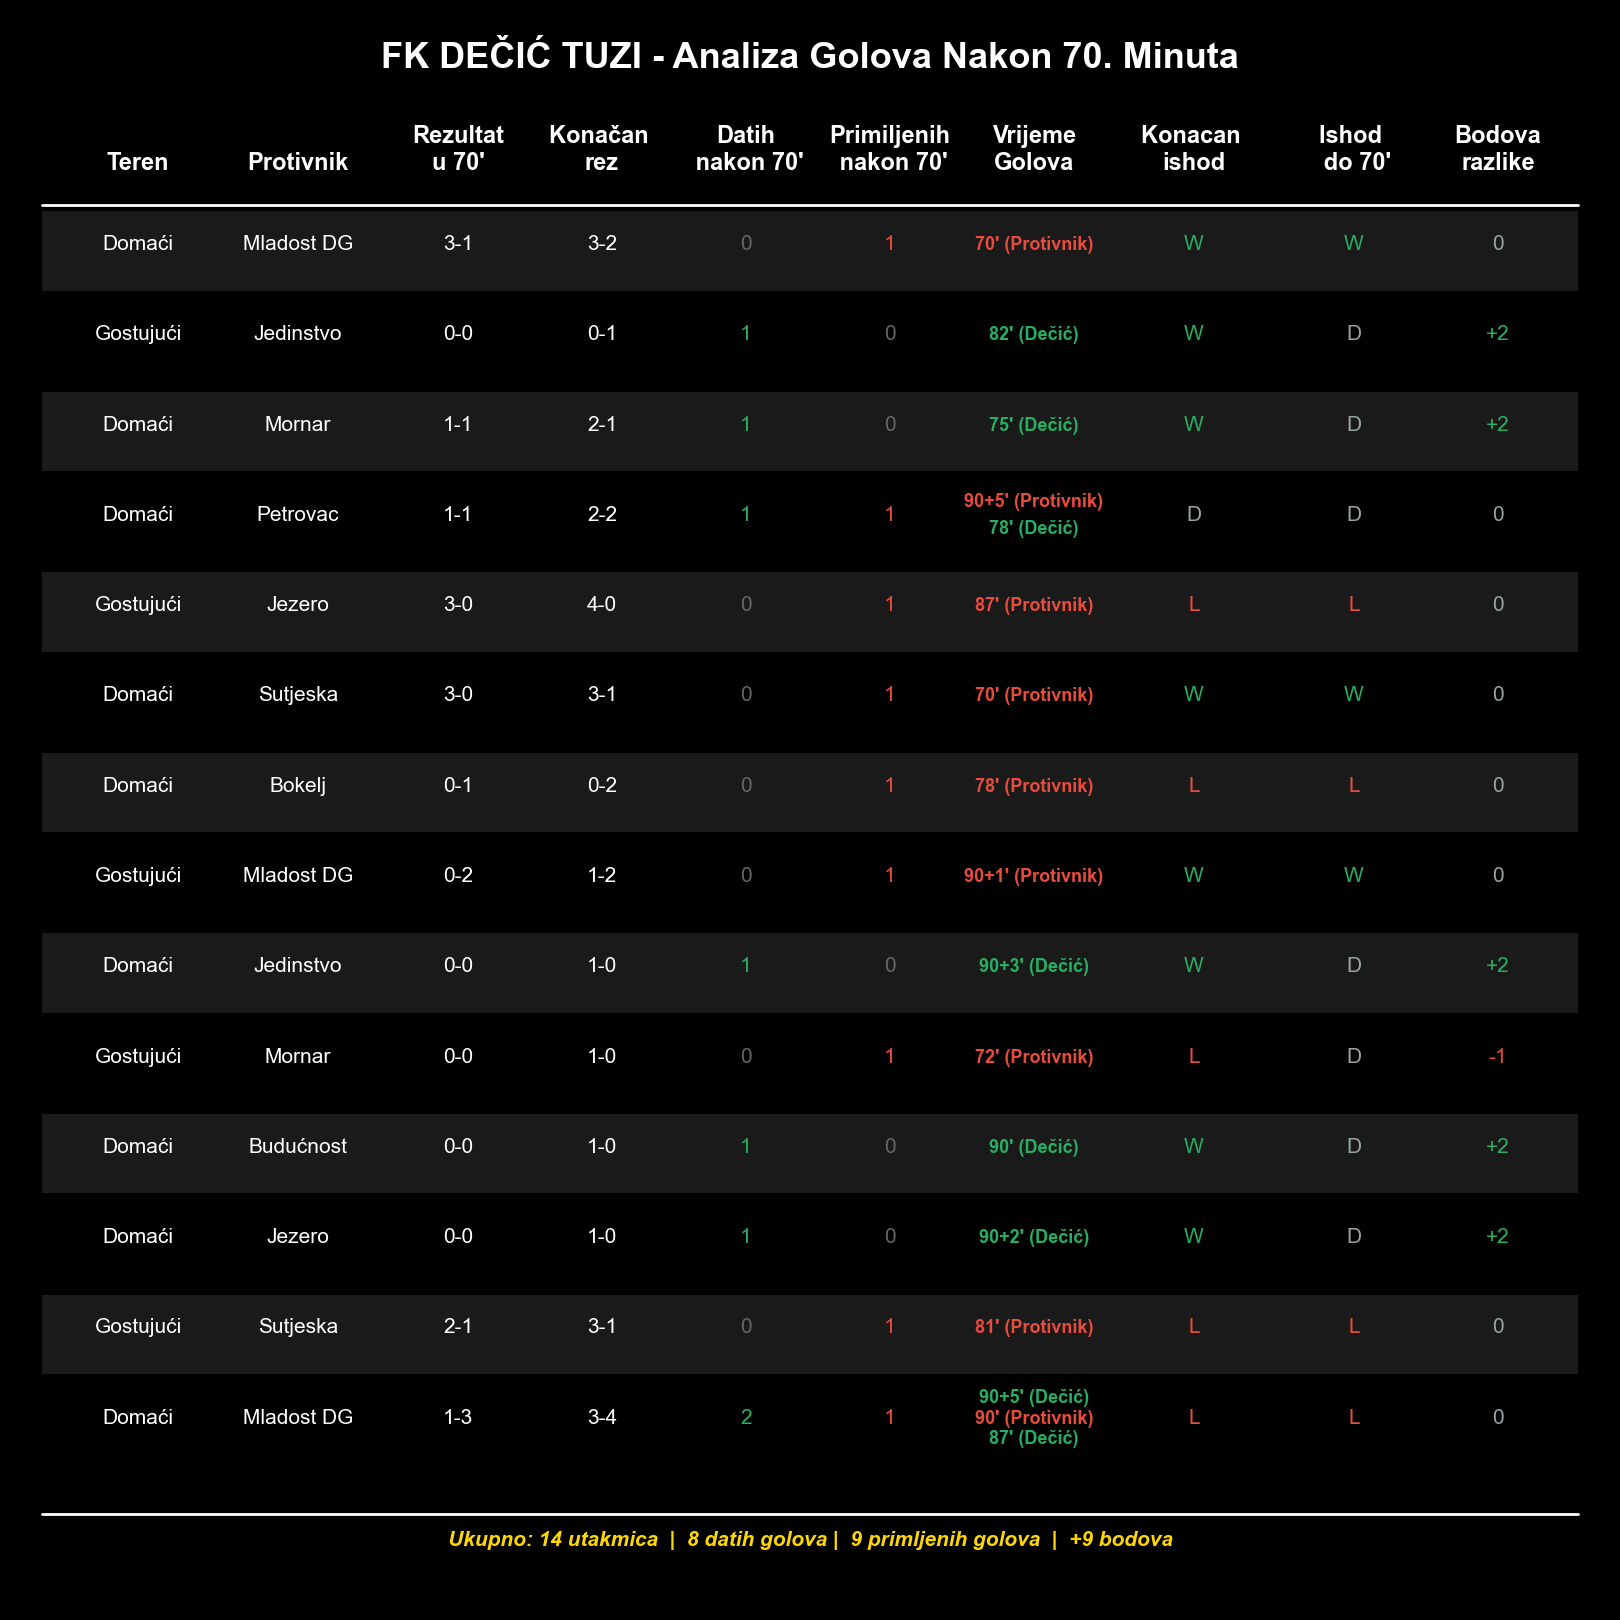

In [416]:
# Create visualization using the reusable function
visualize_team_late_game_breakdown(decic_df, 'FK DEČIĆ TUZI', 'decic_late_game_breakdown.png')

## FK Budućnost Podgorica - Analiza Kasnih Golova

Pregled svih utakmica gdje je FK Budućnost Podgorica dao ili primio gol nakon 70. minuta.

In [417]:
# Generate Budućnost breakdown using the reusable function
buducnost_df = get_team_late_game_breakdown('Budućnost', matches_df, late_game_goals, teams_metadata)

print("FK BUDUĆNOST PODGORICA - UTAKMICE SA GOLOVIMA NAKON 70. MINUTA")
print("="*120)
print(f"\nUkupno utakmica sa kasnim golovima: {len(buducnost_df) - 1}")  # -1 for total row
print(f"Ukupno golova dalo nakon 70': {int(buducnost_df['Dao 70+'].iloc[-1])}")
print(f"Ukupno golova primilo nakon 70': {int(buducnost_df['Primio 70+'].iloc[-1])}")
print(f"Neto bodova od kasnih golova: {buducnost_df['Bodova razlike'].iloc[-1]}")
print("\n")

# Display with better formatting
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
display(buducnost_df)

FK BUDUĆNOST PODGORICA - UTAKMICE SA GOLOVIMA NAKON 70. MINUTA

Ukupno utakmica sa kasnim golovima: 12
Ukupno golova dalo nakon 70': 6
Ukupno golova primilo nakon 70': 9
Neto bodova od kasnih golova: -5




,Teren,Protivnik,Rezultat u 70',Konačan Rezultat,Dao 70+,Primio 70+,Vrijeme Golova,Rezultat,Bi Bilo,Bodova razlike
0,Gostujući,Jezero,1-0,1-2,2,0,"80' (Budućnost), 79' (Budućnost)",W,L,+3
1,Gostujući,Mladost DG,1-1,3-1,0,2,"90' (Protivnik), 73' (Protivnik)",L,D,-1
2,Domaći,Jedinstvo,1-0,1-1,0,1,88' (Protivnik),D,W,-2
3,Gostujući,Mornar,0-1,1-1,0,1,88' (Protivnik),D,W,-2
4,Domaći,Petrovac,1-0,1-1,0,1,75' (Protivnik),D,W,-2
5,Domaći,Jezero,0-1,1-1,1,0,82' (Budućnost),D,L,+1
6,Gostujući,Sutjeska,0-0,0-2,2,0,"78' (Budućnost), 74' (Budućnost)",W,D,+2
7,Domaći,Arsenal Tivat,3-2,4-2,1,0,90+4' (Budućnost),W,W,0
8,Gostujući,Dečić,0-0,1-0,0,1,90' (Protivnik),L,D,-1
9,Domaći,Mladost DG,0-0,0-1,0,1,78' (Protivnik),L,D,-1


## Vizualizacija - FK Budućnost Podgorica

Profesionalna tabela sa svim utakmicama gdje je Budućnost dao ili primio gol nakon 70. minuta.

✅ Figure saved to: outputs/final_posts/buducnost_late_game_breakdown.png


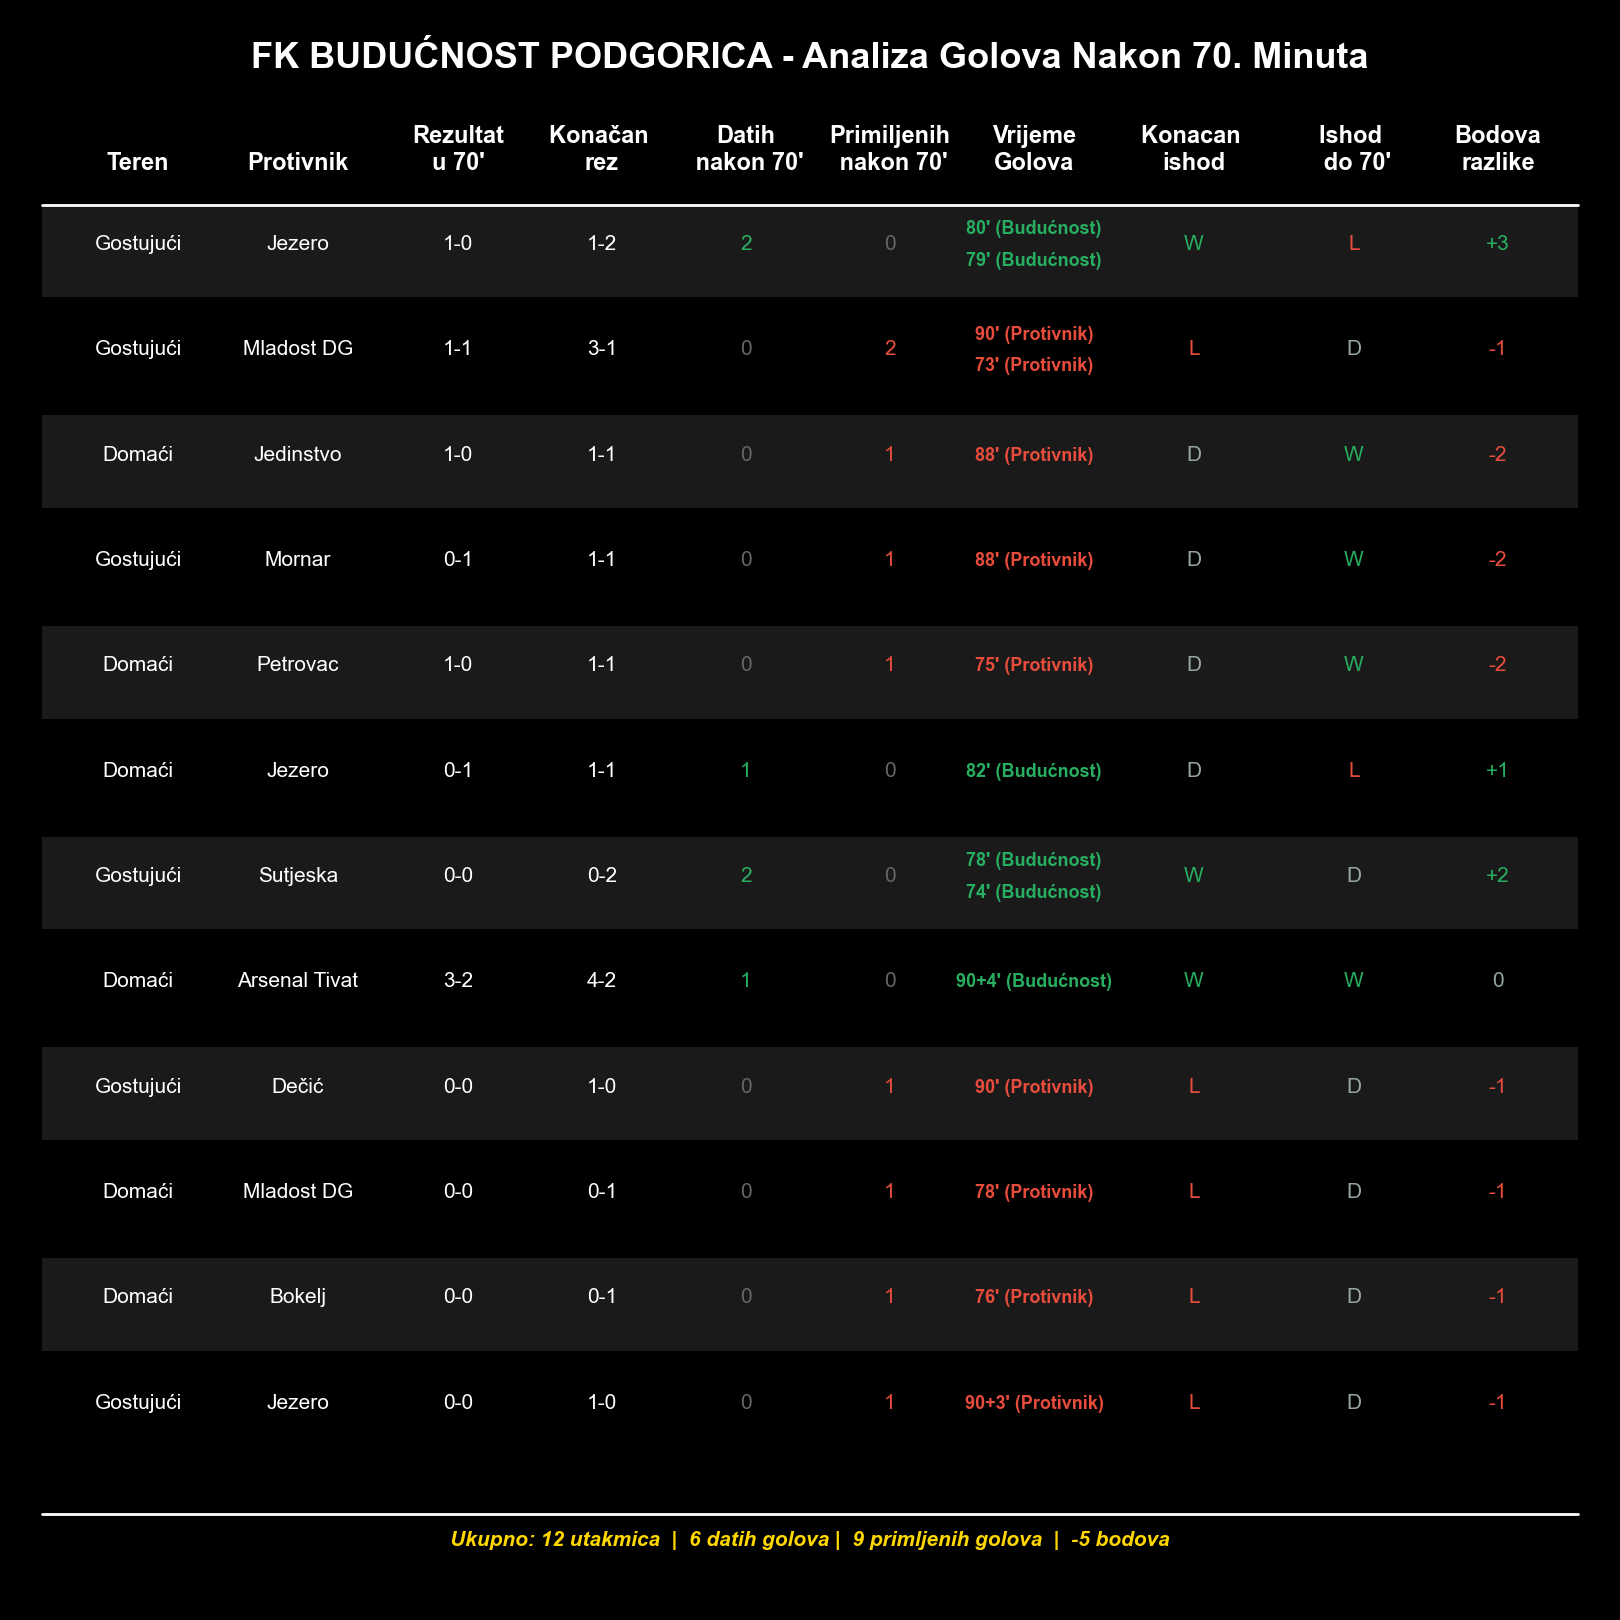

In [418]:
# Create visualization using the reusable function
visualize_team_late_game_breakdown(buducnost_df, 'FK BUDUĆNOST PODGORICA', 'buducnost_late_game_breakdown.png')